In [1]:

from roboflow import Roboflow
rf = Roboflow(api_key="8pKDi256TYNSI88nYikr")
project = rf.workspace("badminton-szmsf").project("ppe-v1-mr-techie-bg8bf")
version = project.version(1)
dataset = version.download("yolo26")
                

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to PPE-V1-Mr.Techie-1 in yolo26:: 100%|██████████| 1795/1795 [00:00<00:00, 16282.27it/s]


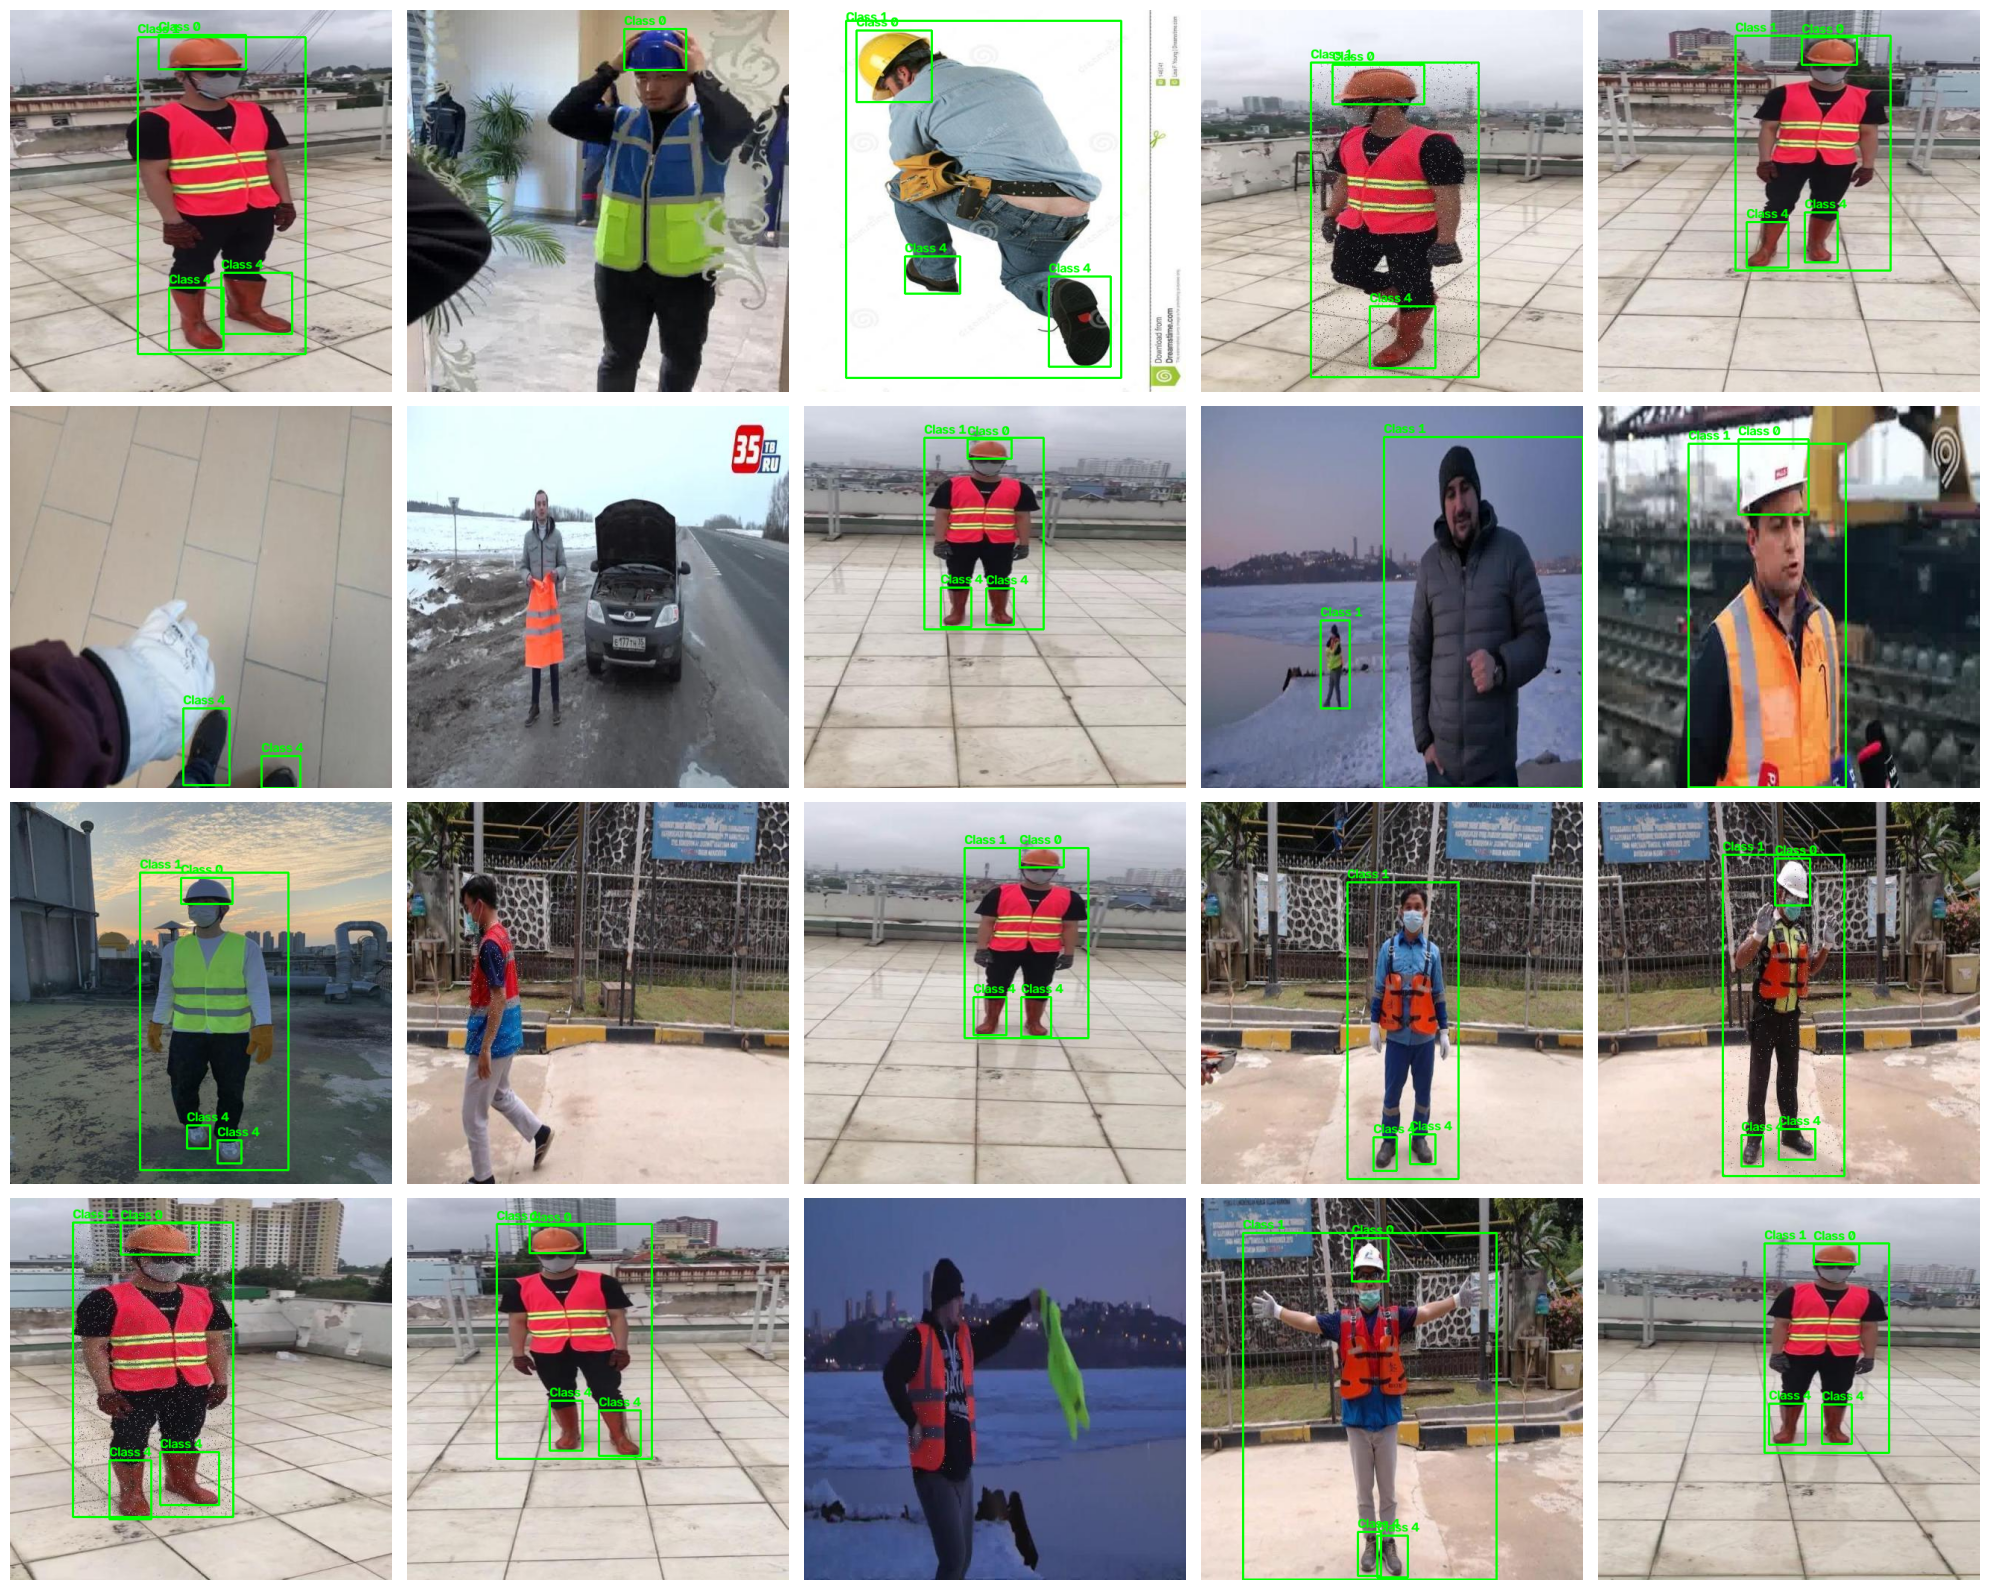

In [15]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

images_dir = Path("PPE-V1-Mr.Techie-1/train/images")
labels_dir = Path("PPE-V1-Mr.Techie-1/train/labels")

images = list(images_dir.glob("*.jpg"))[-40:-20]

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for ax, image_path in zip(axes, images):
    image = cv2.imread(str(image_path))
    h, w = image.shape[:2]

    label_path = labels_dir / f"{image_path.stem}.txt"

    if label_path.exists():
        with open(label_path) as f:
            for line in f:
                cls, xc, yc, bw, bh = map(float, line.split())

                x1 = int((xc - bw / 2) * w)
                y1 = int((yc - bh / 2) * h)
                x2 = int((xc + bw / 2) * w)
                y2 = int((yc + bh / 2) * h)

                cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

                cv2.putText(
                    image,
                    f"Class {int(cls)}",
                    (x1, max(y1 - 5, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0, 255, 0),
                    2
                )

    ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:

labels_dir = Path("PPE-V1-Mr.Techie-1/train/labels")

classes = set()

for label_path in labels_dir.glob("*.txt"):
    with open(label_path) as f:
        for line in f:
            if line.strip():
                classes.add(int(line.split()[0]))

print("Classes found:", sorted(classes))
print("Number of classes:", len(classes))

Classes found: [0, 1, 2, 3, 4]
Number of classes: 5


In [17]:
from ultralytics import YOLO

model = YOLO("yolo26s.pt")

In [18]:
results = model.train(
    data="PPE-V1-Mr.Techie-1/data.yaml",
    epochs=50,
    imgsz=512,
    device=0
)

New https://pypi.org/project/ultralytics/8.4.159 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.120 🚀 Python-3.14.4 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 5806MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=PPE-V1-Mr.Techie-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=30

In [21]:
model = YOLO("/home/mohamed-sameh/Computer_Vision/runs/detect/train/weights/best.pt")

In [22]:
results = model.val(
    data="PPE-V1-Mr.Techie-1/data.yaml",
    imgsz=512,
    device=0
)

Ultralytics 8.4.120 🚀 Python-3.14.4 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 5806MiB)
YOLO26s summary (fused): 122 layers, 9,467,115 parameters, 0 gradients, 20.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2687.6±705.9 MB/s, size: 31.0 KB)
val: Scanning /home/mohamed-sameh/Computer_Vision/YOLO/PPE_Detection/PPE-V1-Mr.Techie-1/valid/labels.cache... 119 images, 12 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 119/119 45.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.5it/s 2.3s0.3ss
                   all        119        411      0.909      0.877      0.896      0.722
                Helmet         88        114      0.892      0.851       0.86      0.637
                Person         95        108      0.943      0.944      0.976      0.882
                 Boots         89        189      0.891      0.836      0.853      0.646
Speed: 0.9ms preprocess, 6.1ms inference, 0.0ms 

In [ ]:
images = [
    "PPE-V1-Mr.Techie-1/train/images/ppe_0137_jpg.rf.374bee7f9a23fb428016666e52b3d9cb.jpg",
    "PPE-V1-Mr.Techie-1/train/images/image_184_jpg.rf.557043ca281b4ced938752e483037852.jpg"
]

results = model.predict(
    source=images,
    imgsz=512,
    conf=0.25,
    device=0,
    save=True
)


0: 512x512 1 Helmet, 1 Person, 1 Ear-protection, 2 Gloves, 2 Bootss, 3.9ms
1: 512x512 1 Person, 2 Gloves, 2 Bootss, 3.9ms
Speed: 6.5ms preprocess, 3.9ms inference, 1.4ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /home/mohamed-sameh/Computer_Vision/runs/detect/predict


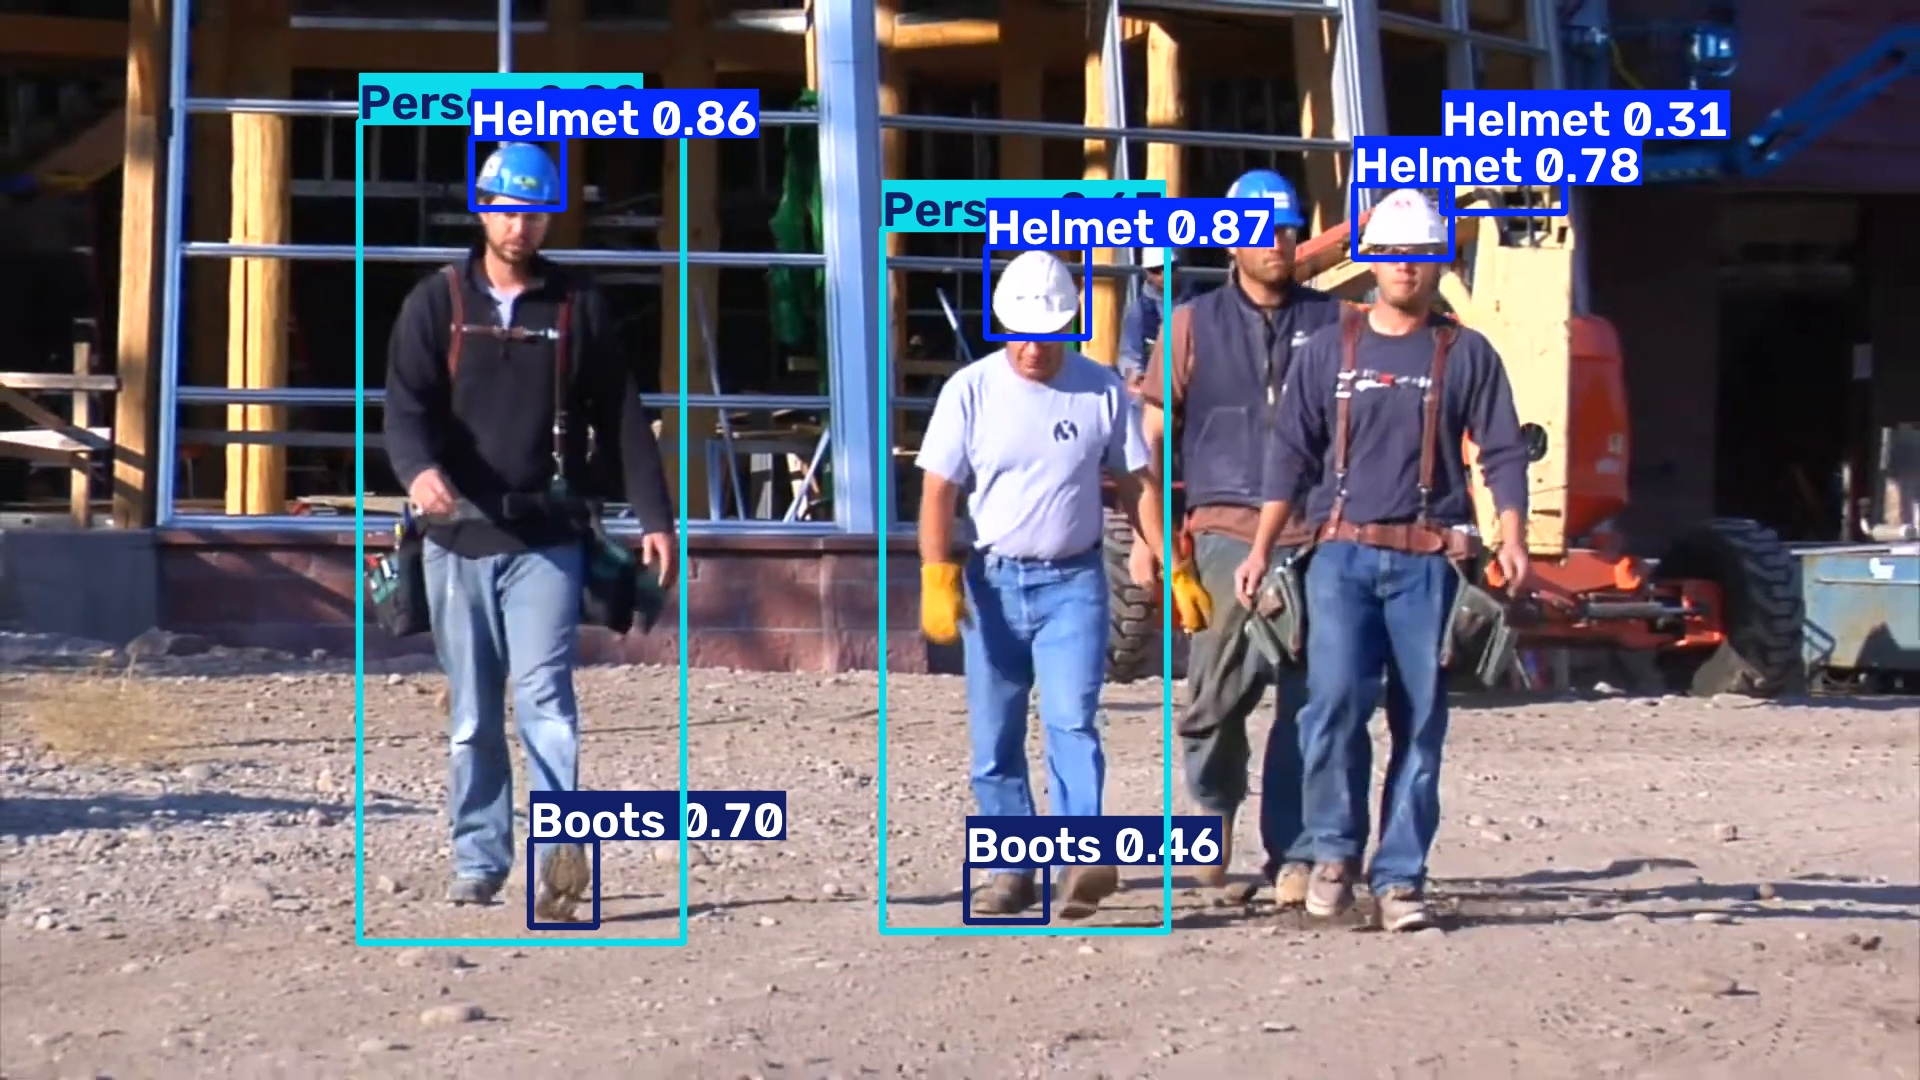

In [27]:
import cv2
from IPython.display import display, Image
from IPython.display import clear_output

video_path = "ppe.mp4"

cap = cv2.VideoCapture(video_path)

while True:
    ret, frame = cap.read()

    if not ret:
        break

    # Run YOLO on the frame
    results = model.predict(frame, imgsz=512, device=0, verbose=False)

    # Draw detections
    annotated_frame = results[0].plot()

    # Convert BGR -> JPEG for notebook display
    _, buffer = cv2.imencode(".jpg", annotated_frame)

    clear_output(wait=True)
    display(Image(data=buffer.tobytes()))

cap.release()